In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define a basic UNet-based denoising model
class SuperResDiffusionUNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1, hidden_dim=64):  # Change in_channels to 2 (1 for noisy image + 1 for condition)
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim * 2, 3, padding=1, stride=2),
            nn.ReLU(),
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 3, padding=1, stride=2),
            nn.ReLU(),
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(hidden_dim * 4, hidden_dim * 4, 3, padding=1),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2, 3, stride=2, output_padding=1, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, 3, stride=2, output_padding=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, out_channels, 3, padding=1),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x)
        return x

# Diffusion model step
class DiffusionModel(nn.Module):
    def __init__(self, unet_model, timesteps=1000):
        super().__init__()
        self.unet = unet_model
        self.timesteps = timesteps

    def forward(self, x, t, condition):
        x = self.unet(torch.cat([x, condition], dim=1))  # Concatenate along channel axis
        return x

# Upsampler function to upscale 20x20 -> 34x34
class Upsampler(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, scale_factor=1.7):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=scale_factor, mode='bilinear', align_corners=True)
        self.conv = nn.Conv2d(in_channels, out_channels, 3, padding=1)

    def forward(self, x):
        x = self.upsample(x)
        return self.conv(x)

# Full model including upsampler and diffusion
class SuperResolutionDiffusion(nn.Module):
    def __init__(self, unet_model, upsampler):
        super().__init__()
        self.upsampler = upsampler
        self.diffusion = DiffusionModel(unet_model)

    def forward(self, x, t):
        upscaled = self.upsampler(x)  # 20x20 -> 34x34
        noise = torch.randn_like(upscaled)  # Add initial noise
        return self.diffusion(noise, t, upscaled)

# Instantiate models
unet = SuperResDiffusionUNet(in_channels=2, out_channels=1)  # 1 input channel + 1 condition channel
upsampler = Upsampler()
model = SuperResolutionDiffusion(unet, upsampler)

# Example input
x = torch.randn(1, 1, 20, 20)  # 1-channel (grayscale) 20x20 input
t = torch.tensor([500])  # Midpoint timestep in diffusion
output = model(x, t)

print("Output shape:", output.shape)  # Should be [1, 1, 34, 34]


Output shape: torch.Size([1, 1, 36, 36])


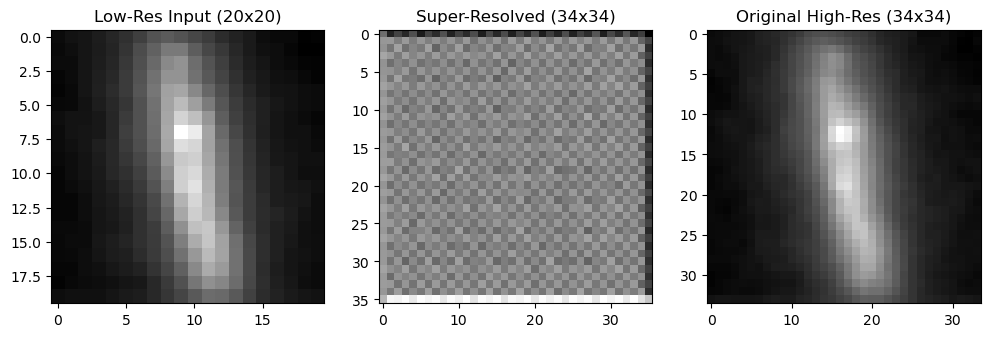

In [14]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

# Load a grayscale image and resize to 34x34
img = Image.open('test_image.png').convert('L')  # Load a grayscale image
transform = transforms.Compose([
    transforms.Resize((34, 34)),
    transforms.ToTensor()
])

high_res = transform(img).unsqueeze(0)  # Shape: [1, 1, 34, 34]

# Downsample to 20x20 (simulate low-res input)
low_res_transform = transforms.Resize((20, 20))
low_res = low_res_transform(img)
low_res = transforms.ToTensor()(low_res).unsqueeze(0)  # Shape: [1, 1, 20, 20]

# Run the model
t = torch.tensor([500])  # Midpoint timestep
model.eval()
with torch.no_grad():
    super_res = model(low_res, t)

# Convert tensors to numpy for visualization
low_res_np = low_res.squeeze().cpu().numpy()
super_res_np = super_res.squeeze().cpu().numpy()
high_res_np = high_res.squeeze().cpu().numpy()

# Plot results
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(low_res_np, cmap='gray')
ax[0].set_title("Low-Res Input (20x20)")
ax[1].imshow(super_res_np, cmap='gray')
ax[1].set_title("Super-Resolved (34x34)")
ax[2].imshow(high_res_np, cmap='gray')
ax[2].set_title("Original High-Res (34x34)")
plt.show()


# Prepare data

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define data transformations
transform_hr = transforms.Compose([
    transforms.Grayscale(),  # Convert to grayscale
    transforms.Resize((34, 34)),  # High-res size
    transforms.ToTensor()
])

transform_lr = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((20, 20)),  # Low-res size
    transforms.ToTensor()
])

# Load dataset (example: DIV2K)
dataset = datasets.ImageFolder(root='data/DIV2K', transform=transform_hr)
dataset_lr = datasets.ImageFolder(root='data/DIV2K', transform=transform_lr)

# Combine high-res and low-res pairs
class SuperResolutionDataset(torch.utils.data.Dataset):
    def __init__(self, hr_data, lr_data):
        self.hr_data = hr_data
        self.lr_data = lr_data

    def __len__(self):
        return len(self.hr_data)

    def __getitem__(self, idx):
        hr_image, _ = self.hr_data[idx]
        lr_image, _ = self.lr_data[idx]
        return lr_image, hr_image

# Create dataset and loader
train_dataset = SuperResolutionDataset(dataset, dataset_lr)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


# Add noise

In [ ]:
import torch

def add_noise(x, t, noise_schedule):
    noise = torch.randn_like(x)
    alpha_t = noise_schedule[t].view(-1, 1, 1, 1)  # Scaling factor per timestep
    return alpha_t * x + (1 - alpha_t) * noise

# Example noise schedule (linear)
timesteps = 1000
noise_schedule = torch.linspace(0.1, 1.0, steps=timesteps)

# Sample batch
for lr, hr in train_loader:
    t = torch.randint(0, timesteps, (lr.shape[0],))  # Random timesteps per image
    noisy_hr = add_noise(hr, t, noise_schedule)
    break  # Only show one batch


# Train

In [ ]:
import torch.optim as optim

# Define model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SuperResolutionDiffusion(unet, upsampler).to(device)

# Define loss function and optimizer
criterion = nn.MSELoss()  # Can also try SSIM loss or perceptual loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for lr, hr in train_loader:
        lr, hr = lr.to(device), hr.to(device)

        # Select random timesteps
        t = torch.randint(0, timesteps, (lr.shape[0],), device=device)

        # Add noise to HR images
        noisy_hr = add_noise(hr, t, noise_schedule.to(device))

        # Model predicts the original HR image
        predicted_hr = model(lr, t)

        # Compute loss
        loss = criterion(predicted_hr, hr)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.6f}")


# Evaluate 

In [ ]:
import matplotlib.pyplot as plt

# Load a test image (Low-res input)
test_lr, test_hr = train_dataset[0]
test_lr = test_lr.unsqueeze(0).to(device)

# Run model on test image
model.eval()
with torch.no_grad():
    t = torch.tensor([500], device=device)  # Middle diffusion step
    predicted_hr = model(test_lr, t).cpu().squeeze()

# Plot the results
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(test_lr.squeeze().cpu(), cmap='gray')
ax[0].set_title("Low-Res Input (20x20)")
ax[1].imshow(predicted_hr, cmap='gray')
ax[1].set_title("Super-Resolved (34x34)")
ax[2].imshow(test_hr.squeeze(), cmap='gray')
ax[2].set_title("Ground Truth (34x34)")
plt.show()
